In [20]:
import cooperative_tasep_lib as tasep
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from joblib import Parallel, delayed
from scipy import stats

In [66]:
L = 300
T = 1000
q = 1
kon = 1
koff = 1
kstep = 10
kq = 0.1


In [28]:
# data, activation, nn, times, res, dts = tasep.ssim(L, T, kon, koff, 1, kq, q)
data, actiation, nn, times, res, dts = tasep.ssim(L, T, kon, koff, 100, 100, 10)

In [29]:
left = -nn[:,0]
right = nn[:,1]

In [30]:
stats.ttest_rel(left, right)

TtestResult(statistic=6.09253296019643, pvalue=1.1284213333437892e-09, df=23817)

In [20]:
all_nn = np.hstack([left, right])

In [6]:
def count(dis):
    x = np.arange(0, 21, dtype=np.int16)
    counts = [np.sum(dis==i) for i in x ]
    return x, np.array(counts, dtype=np.int32)/len(dis)

In [7]:
x, y_l = count(-left)
x, y_r = count(right)

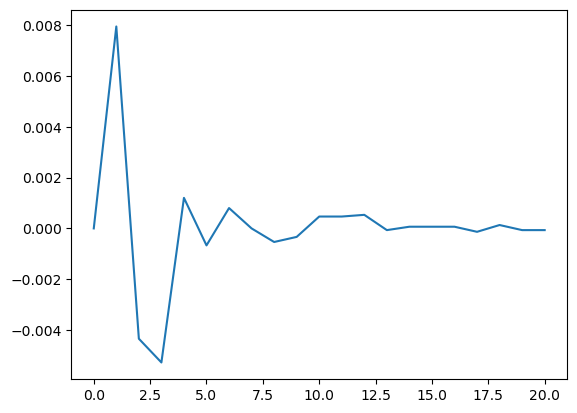

In [8]:
plt.plot(x,y_l-y_r)


In [46]:
def count(nn):
    left = nn[:,0]
    right = nn[:,1]
    nn = np.hstack([left,right])
    x = np.arange(-20, 21, dtype=np.int16)
    counts = [np.sum(nn==i) for i in x ]
    left = -left
    t, p_val = stats.ttest_rel(left, right)
    return x, np.array(counts, dtype=np.int32)/len(left) , p_val

In [47]:


Q = [1, 5, 10]
KQ = [10, 50, 100]
KSTEP = [10, 50, 100]





In [70]:
def main_job(q, kq, kstep):
    L = 600
    T = 2000
    kon = 0.1
    koff = 1

    data, actiation, nn, times, res, dts = tasep.ssim(L, T, kon, koff, kstep, kq, q)
    x, y ,p_val = count(nn)
    return (y, {"q":q, "kq":kq, "kstep":kstep, "p_val":p_val})


In [71]:
res = Parallel(n_jobs = 9)(
    delayed(main_job)(q,kq,kstep)
    for kq in KQ
    for kstep in KSTEP
    for q in Q
)

In [54]:
def exp(x, a):
    return 1/a*np.exp(-a*x)

Text(0.5, 0.98, 'KON = 0.1')

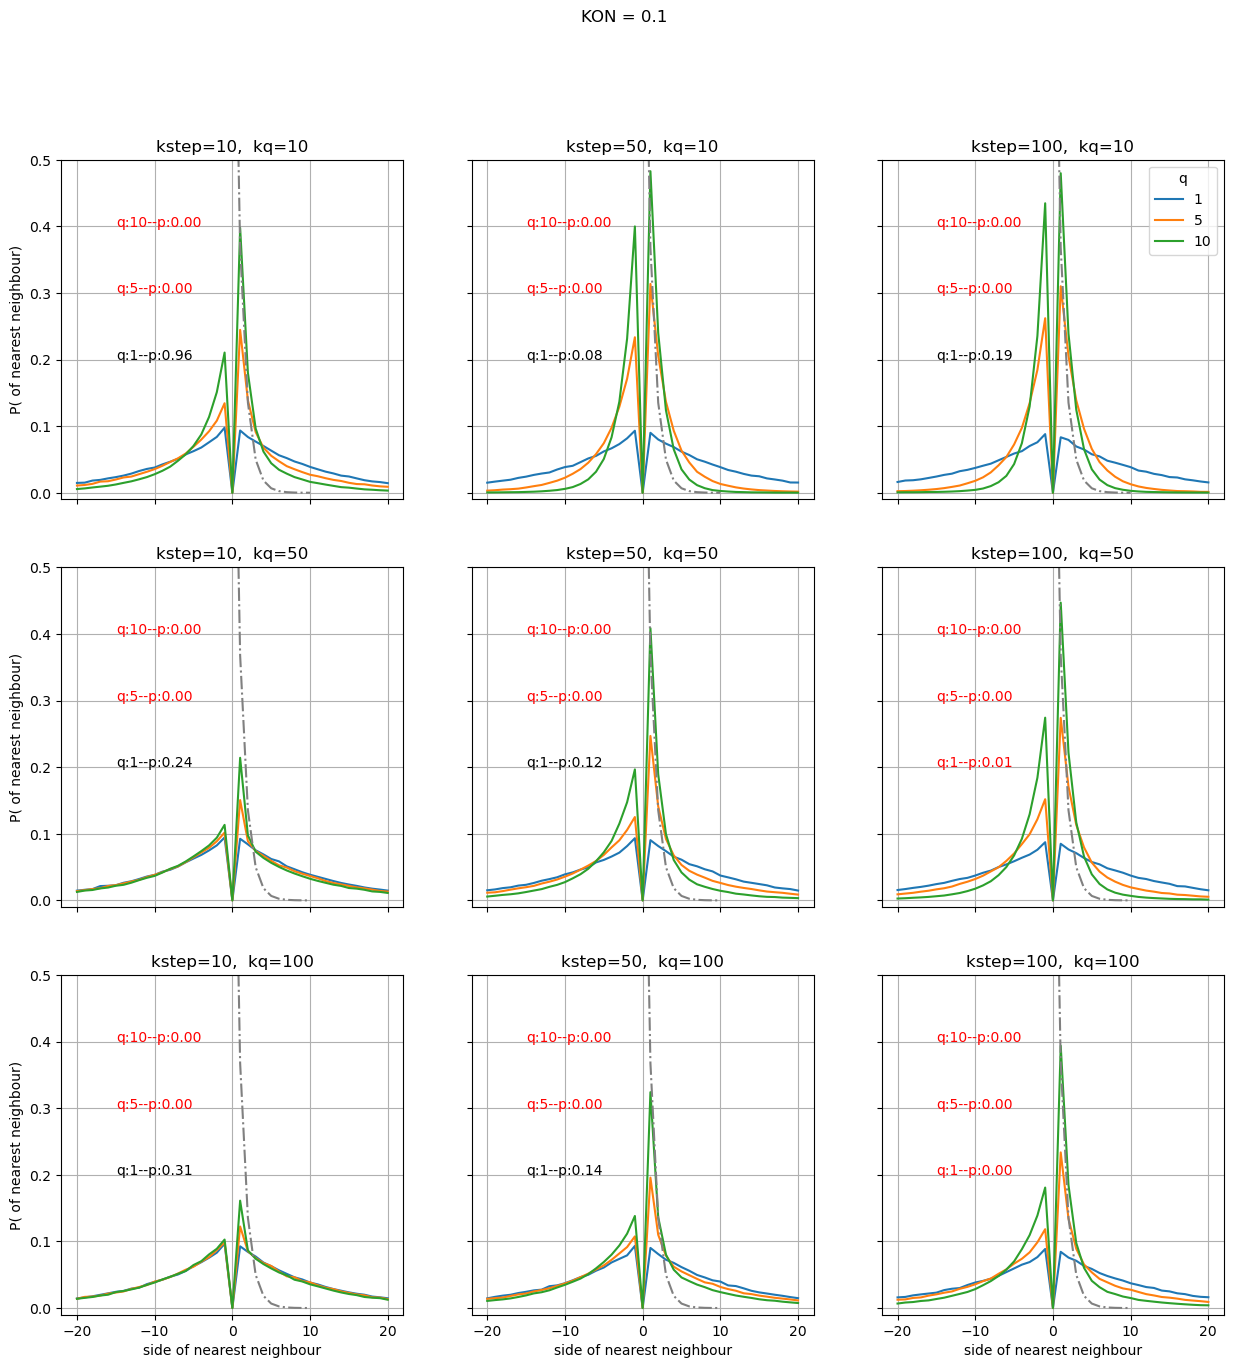

In [72]:
fig, axes = plt.subplots(3,3, figsize=(15,15), sharex=True, sharey=True)
x_th = np.arange(0,11)
y_th = exp(x_th, 1)
x = np.arange(-20, 21, dtype=np.int16)

for row, kq in enumerate(KQ):
    for col, kstep in enumerate(KSTEP):
        ax = axes[row][col]
        for i, q in enumerate(Q):
            line, meta = res[9*row+3*col+i]
            p_val = meta["p_val"]
            ax.plot(x, line, label=f"{q}")
            c = "red" if p_val<0.05 else "k"               
            ax.text(-15, 0.2+0.1*i, f"q:{q}--p:{p_val:.2f}", color=c)
        
        ax.plot(x_th, y_th, c="grey", linestyle="-.")
        ax.grid()
        ax.set(title=f"kstep={kstep},  kq={kq}", ylim=[-0.01, 0.5])

        if col==0:
            ax.set(ylabel = "P( of nearest neighbour)")
        if row==2:
            ax.set(xlabel = "side of nearest neighbour")

        if col==2 and row==0:
            ax.legend(title = 'q')

plt.suptitle("KON = 0.1")

In [73]:
fig.savefig("p_val.png", dpi=300)

In [74]:
CLEAR_DATA = [r[1] for r in res]

In [75]:
import pandas as pd

df = pd.DataFrame(CLEAR_DATA)

In [76]:
df["is_significant"] = df["p_val"].apply(lambda x: x<0.05)

In [80]:
df = df.sort_values(by=["q", "kstep"])

In [81]:
df.to_latex("overleaf.txt")

In [19]:
from scipy import stats

array([0, 0, 0, ..., 2, 2, 3], dtype=int32)

Text(0.5, 0.98, 'KON = 0.1')

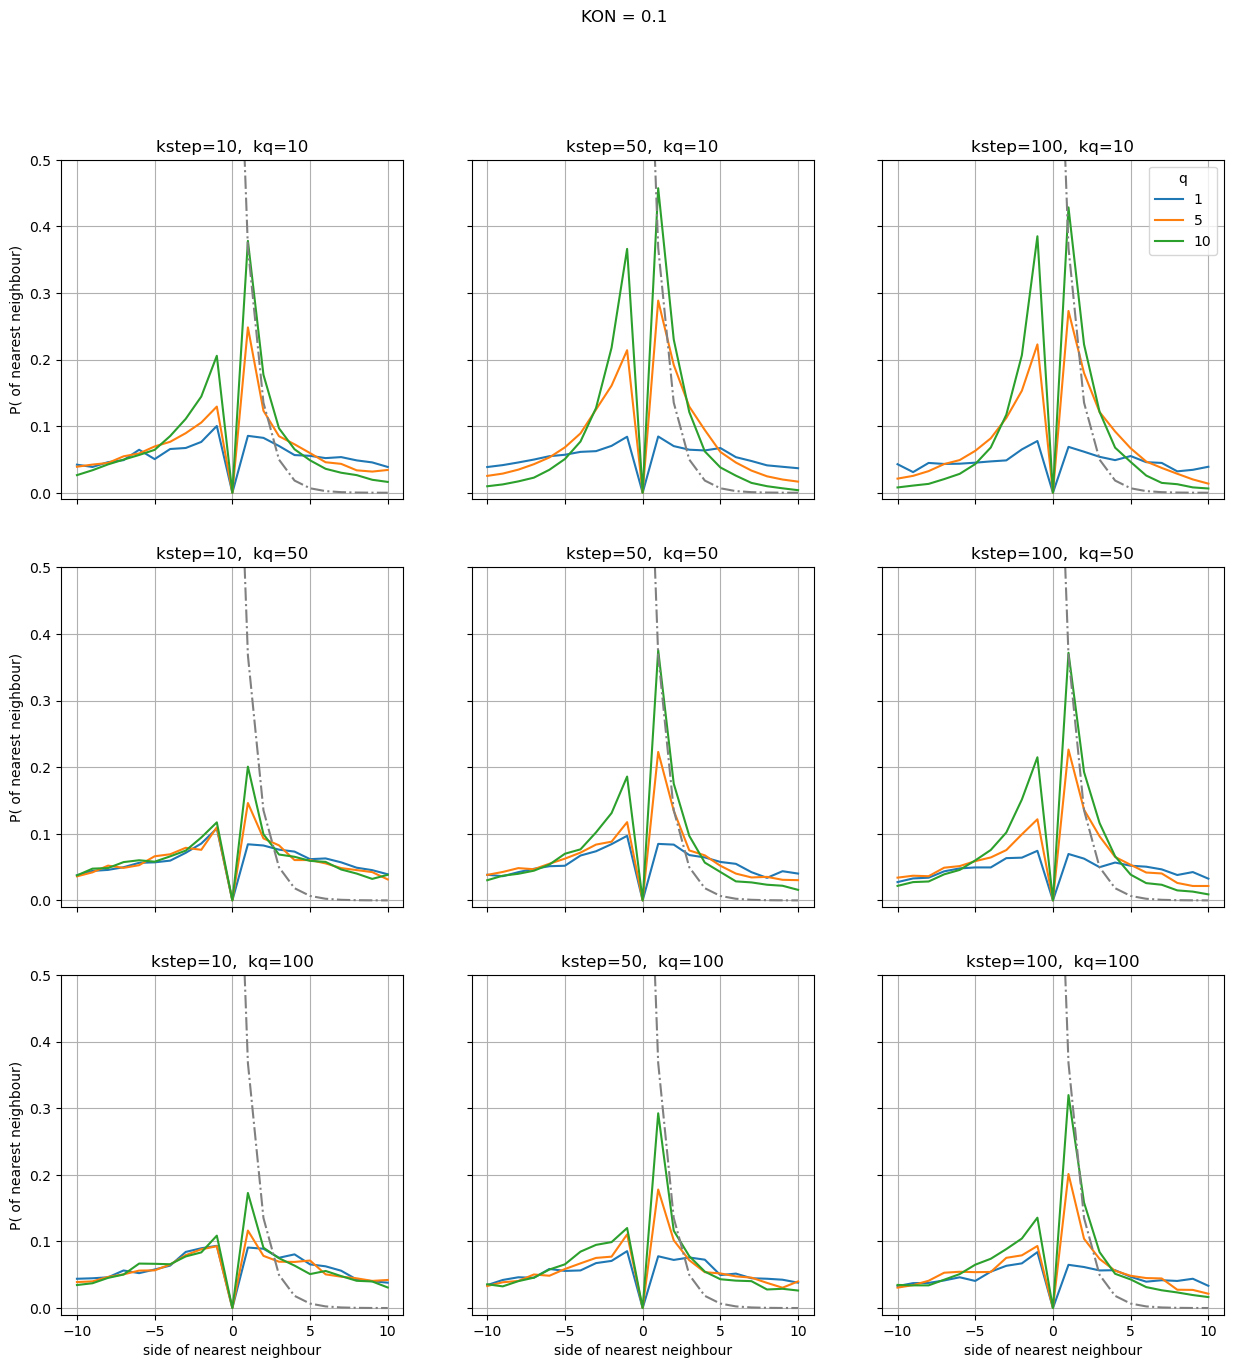

In [141]:
fig, axes = plt.subplots(3,3, figsize=(15,15), sharex=True, sharey=True)
x_th = np.arange(0,11)
y_th = exp(x_th, 1)

for row, kq in enumerate(KQ):
    for col, kstep in enumerate(KSTEP):
        ax = axes[row][col]
        for i, q in enumerate(Q):
            ax.plot(x, res[9*row+3*col+i], label=f"{q}")
        
        ax.plot(x_th, y_th, c="grey", linestyle="-.")
        ax.grid()
        ax.set(title=f"kstep={kstep},  kq={kq}", ylim=[-0.01, 0.5])

        if col==0:
            ax.set(ylabel = "P( of nearest neighbour)")
        if row==2:
            ax.set(xlabel = "side of nearest neighbour")

        if col==2 and row==0:
            ax.legend(title = 'q')

plt.suptitle("KON = 0.1")

In [142]:
fig.savefig("kon_0.1.png", dpi=500)

Text(0.5, 0.98, 'KON = 0.1')

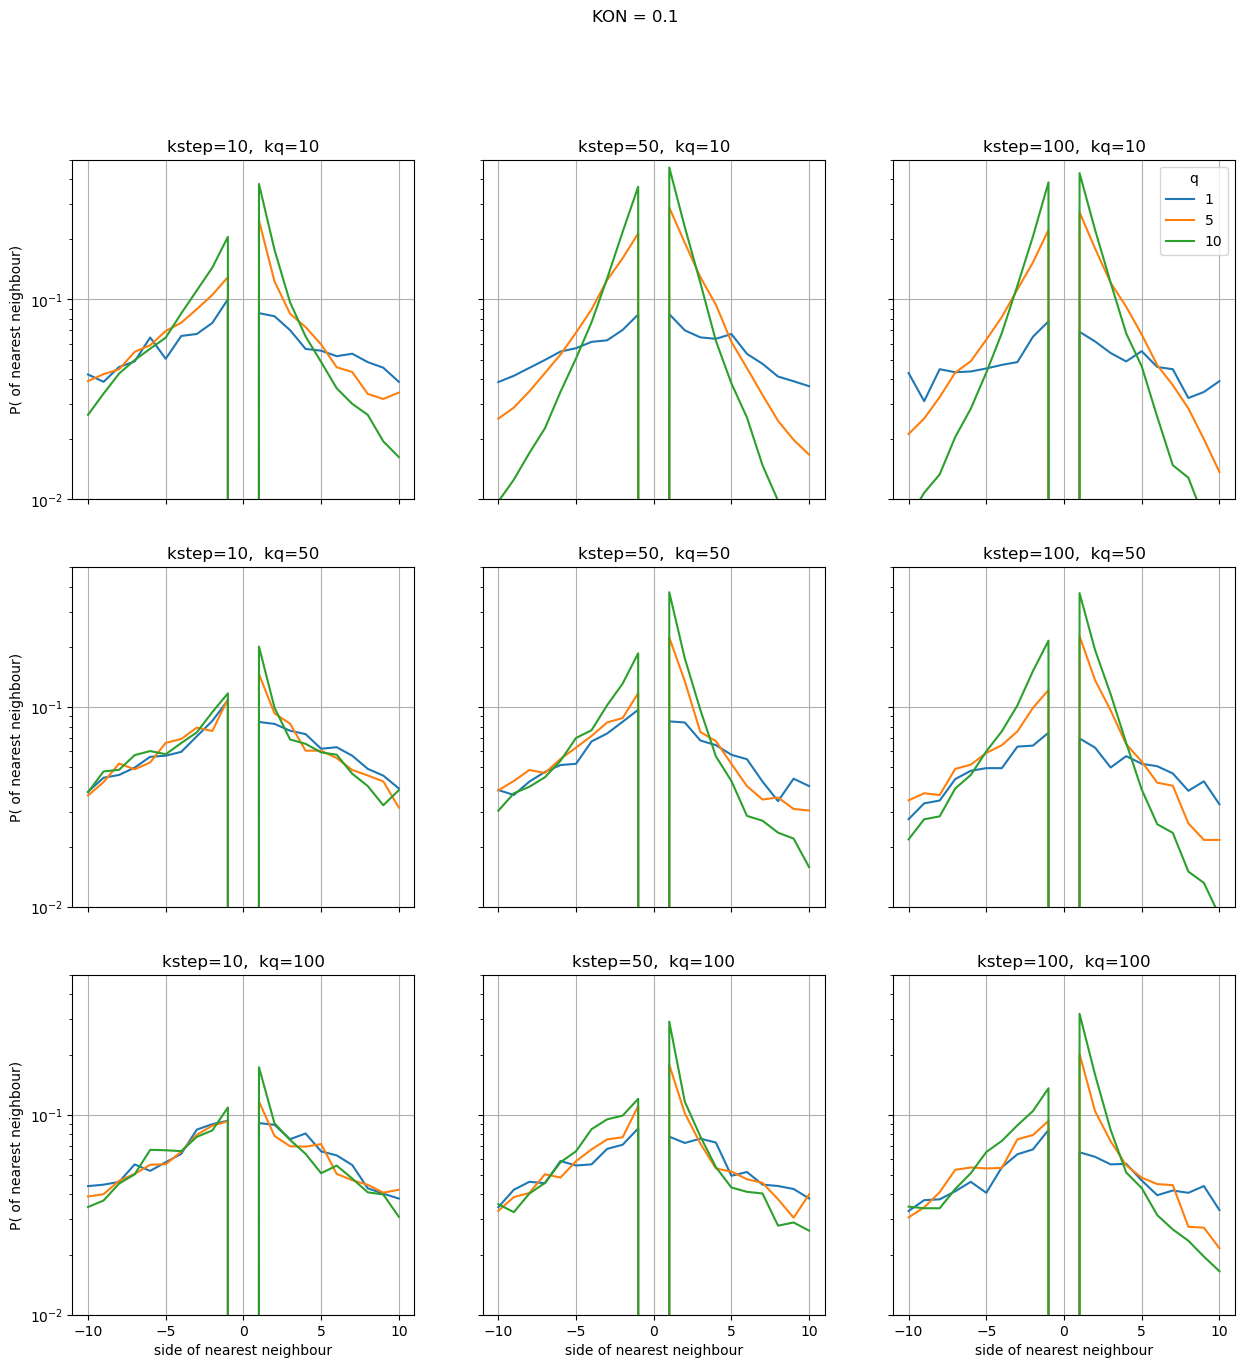

In [143]:
fig, axes = plt.subplots(3,3, figsize=(15,15), sharex=True, sharey=True)

for row, kq in enumerate(KQ):
    for col, kstep in enumerate(KSTEP):
        ax = axes[row][col]
        for i, q in enumerate(Q):
            ax.plot(x, res[9*row+3*col+i], label=f"{q}")
        
        # ax.plot(x_th, y_th, c="grey", linestyle="-.")
        ax.grid()
        ax.set(title=f"kstep={kstep},  kq={kq}", ylim=[0.01, 0.5], yscale="log")

        if col==0:
            ax.set(ylabel = "P( of nearest neighbour)")
        if row==2:
            ax.set(xlabel = "side of nearest neighbour")

        if col==2 and row==0:
            ax.legend(title = 'q')

plt.suptitle("KON = 0.1")

In [144]:
fig.savefig("kon_0.1_log.png", dpi=500)

In [157]:
data, actiation, nn_a, times, res, dts = tasep.ssim(L, 400, 0.1, koff, 100, 100, 1)
data, actiation, nn_b, times, res, dts = tasep.ssim(L, 400, 0.1, koff, 100, 100, 10)
data, actiation, nn_c, times, res, dts = tasep.ssim(L, 400, 1, koff, 100, 100, 1)



[None]

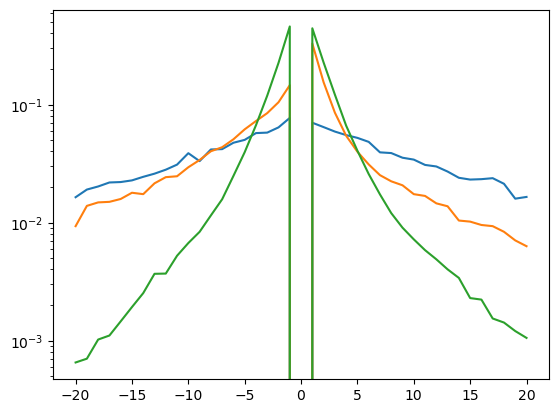

In [161]:
fig, ax = plt.subplots(1,1)

ax.plot(x_a, y_a)
ax.plot(x_b, y_b)
ax.plot(x_c, y_c)

ax.set(yscale="log")

